# Assignment 1 - Part 2 - Amazon Reviews

## Introdcution:

This assignment is the second part of a two-part project and focuses on analyzing the Amazon Reviews dataset, specifically the Software category. The objective of this section is to explore the dataset and address a series of questions provided by the professor. Unlike Part 1, this report will include less emphasis on methodology, as it largely follows the same approach used previously, with only the dataset differing. For a detailed explanation of the methodology, please refer to Part 1.

### Import Statements

In [1]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as pn

### Reading Files

In contrast to Part 1, this section uses a JSON file rather than CSV files. Fortunately, Pandas can easily handle this format using the read_json() method.

In [2]:
#Reading Files
meta_Software = pd.read_json('meta_Software.jsonl', lines=True)
software_csv = pd.read_csv('Software.csv')

#Simple Debug Statement
print('meta_Software.jsonl preview:')
print(meta_Software.head())
print("\nmeta_Software.jsonl shape:")
print(meta_Software.shape)
print("\nmeta_Software.jsonl info:")
print(meta_Software.info())
print()
print('\nSoftware.csv preview:')
print(software_csv.head())
print("\nSoftware.csv shape:")
print(software_csv.shape)
print("\nSoftware.csv info:")
print(software_csv.info())

meta_Software.jsonl preview:
          main_category                                              title  \
0  Appstore for Android                                 Accupressure Guide   
1  Appstore for Android  Ankylosaurus Fights Back - Smithsonian's Prehi...   
2  Appstore for Android                                       Mahjong 2015   
3  Appstore for Android                              Jewels Brick Breakout   
4  Appstore for Android                       Traffic Police: Off-Road Cub   

   average_rating  rating_number  \
0             3.6            NaN   
1             4.0            NaN   
2             3.1            NaN   
3             4.2            NaN   
4             3.3            NaN   

                                            features  \
0  [All the pressing point has been explained wit...   
1  [ENCOURAGE literacy skills with highlighted na...   
2  [Mahjong 2015 is a free solitaire matching gam...   
3  [Game Features:, - Intuitive touch controls wi...   
4  [I

## Basic Info:

### How Many?
The first section asks us to determine the following attributes of the dataset:

* How many items are in the data set?
* How many users?
* How many ratings?
* What is the density of the data set?

In [3]:
# How many items are in the basic data set?
num_items = software_csv['parent_asin'].nunique()
print('Items in the dataset:', num_items)

#How many users in the data set?
num_users = software_csv['user_id'].nunique()
print("Users in the dataset:",num_users)

#How many ratings in the data set?
num_ratings = len(software_csv)
print('Ratings in the dataset',num_ratings)

#Density of the Data Set
density = num_ratings / (num_items * num_users)
print('Density:', density)

Items in the dataset: 89246
Users in the dataset: 2589466
Ratings in the dataset 4828480
Density: 2.0893512806366765e-05


There is very little to say here in terms of analysis, as the variables are fairly straightforward. The only point worth noting is that the dataset is highly sparse, with a density of only about 0.002%.

### Distribution of User Rating Counts

The question asks: _“What is the distribution of user rating counts?”_. 

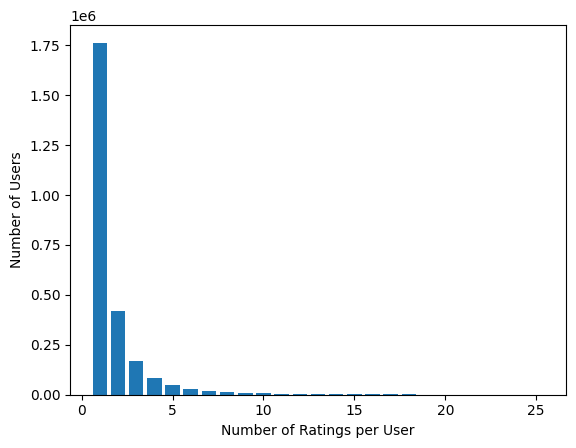

In [4]:
#Distribution of user rating counts
user_stats = software_csv.groupby('user_id')['rating'].count()
user_stats = user_stats.to_frame('n_ratings')
counts = user_stats[user_stats['n_ratings'] <= 25]['n_ratings'].value_counts().sort_index()

#Tried to filter some outliers here to the graph is somewhat readable
plt.bar(counts.index, counts.values)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.show()

As expected, most users contribute only a small number of ratings, with the majority falling under 10. As the number of ratings increases, the distribution drops off sharply, indicating that progressively fewer users are highly active in the dataset.

### Popularity Curve

This question asks, _“What is the item popularity curve (the distribution of ratings-per-item)?”_

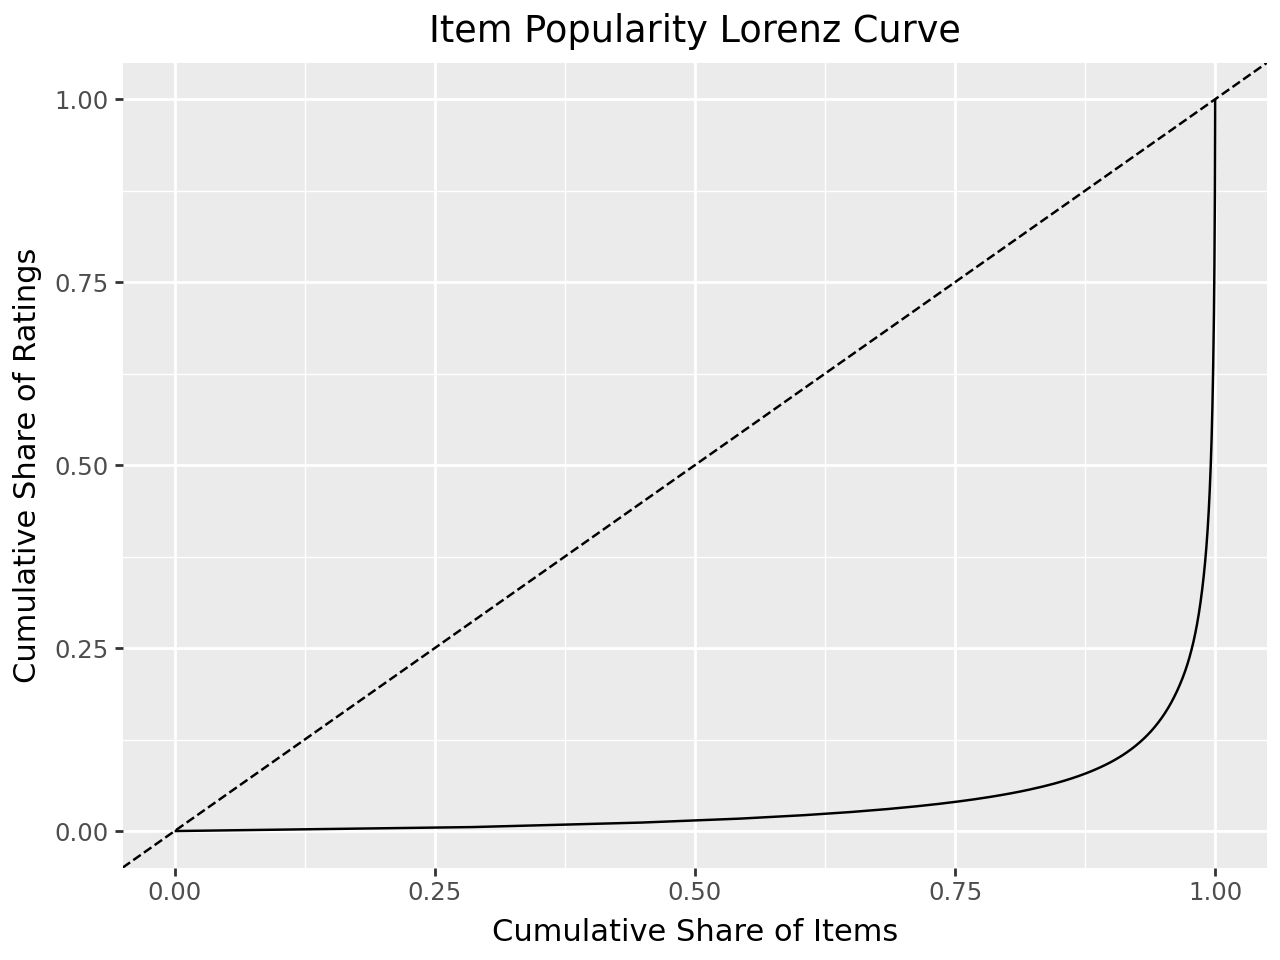

In [5]:
#What is the item popularity curve
item_stats = software_csv.groupby('parent_asin')['rating'].count()
item_stats = item_stats.to_frame('n_rating')
item_stats = item_stats.sort_values('n_rating')

item_stats['prob'] = item_stats['n_rating'] / item_stats['n_rating'].sum()

#What is the item popularity curve (the distribution of ratings-per-item)
item_stats['cum_items'] = np.arange(1, len(item_stats) + 1) / len(item_stats)

#Compute cumulative share of ratings
item_stats['cum_ratings'] = item_stats['n_rating'].cumsum() / item_stats['n_rating'].sum()

#Plot Lorenz curve
(
    pn.ggplot(item_stats)
    + pn.aes(x='cum_items', y='cum_ratings')
    + pn.geom_line()
    + pn.geom_abline(slope=1, intercept=0, linetype='dashed')  # equality line
    + pn.labs(x='Cumulative Share of Items', y='Cumulative Share of Ratings')
    + pn.ggtitle('Item Popularity Lorenz Curve')
)

As observed in the CDF plot from the previous analysis, the Lorenz curve similarly indicates a highly skewed distribution of item popularity. A small proportion of items account for a large share of total ratings, while the majority of items receive relatively few interactions.

### Average Rating Distribution for Items

The question asks,_"What is the distribution of average ratings for items?"_

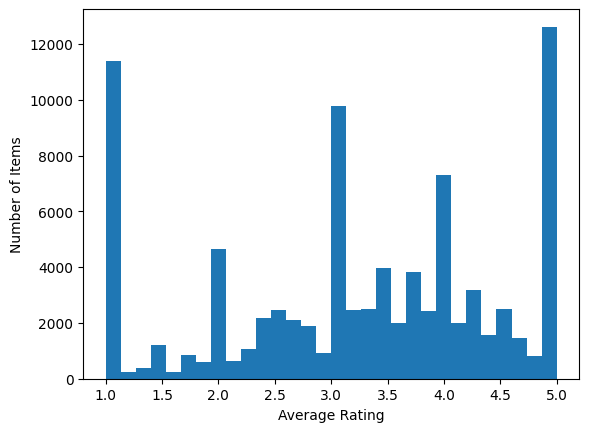

In [6]:
# What is the distribution of average ratings for items
item_stats['mean'] = software_csv.groupby('parent_asin')['rating'].agg('mean')
plt.hist(item_stats['mean'],bins=30)
plt.xlabel('Average Rating')
plt.ylabel('Number of Items')
plt.show()

Contrary to the previous dadtaset (where most average item ratings were concentrated between 3 and 4) this distribution appears more polarized. The most common average ratings are 5, 1, and 3, indicating a tendency toward extreme or mid-point evaluations rather than a smooth central clustering. This pattern is consistent with user review behavior on platforms like Amazon, where users are more likely to leave feedback when they have particularly positive or negative experiences. As a result, ratings tend to cluster at the high and low ends of the scale, with fewer items receiving consistently moderate evaluations.

## Non-Personalized Recommendation:

### Items With the Most Ratings

The question asks: _“What are the 10 most popular items (the items with the most ratings)? Show the item ID, item title, and the number of ratings.”_

In [7]:
#Merged json and csv to have both parent_asin and movie title
merged_df = pd.merge(meta_Software,software_csv, on='parent_asin')

#Added Number of Ratings
num_ratings = (
    merged_df
    .groupby(['parent_asin', 'title'])
    .size()
    .reset_index(name='number_of_ratings')
)


# #Top 10 Most Popular Items
num_ratings.nlargest(10,'number_of_ratings').reset_index(drop=True)

,parent_asin,title,number_of_ratings
0,B00FAPF5U0,Candy Crush Saga,50326
1,B00N28818A,Amazon Prime Video,46369
2,B00992CF6W,Minecraft,43720
3,B005ZXWMUS,Netflix,32780
4,B0094BB4TW,Facebook,29976
5,B00KDSGIPK,Pluto TV - It’s Free TV,27435
6,B01N0BP507,Downloader,26842
7,B00QW8TYWO,Crossy Road,26548
8,B017250D16,Paramount+,25786
9,B07T771SPH,YouTube,24895


The section is titled _Non-personalized Recommendation_, meaning that recommendations are generated without considering individual user preferences. Instead, this approach relies on a simple popularity-based strategy, where items are ranked by the total number of ratings they receive and the top-ranked items are recommended to all users.

The results show that highly popular apps such as Candy Crush Saga, Amazon Prime Video, and Minecraft dominate the top of the list, each receiving tens of thousands of ratings. This approach assumes that frequently rated items are the most desirable; however, this is a strong simplification. High rating counts primarily reflect visibility and usage rather than quality or relevance to any specific user.

As a result, while this method is straightforward and often used as a baseline, it does not account for differences in user taste. Popularity-based recommendations can therefore be biased toward widely used or heavily promoted apps, rather than those that would best match individual preferences.

### Items With the Highest Average Ratings

The question asks: _“What are the 10 items with the highest average ratings (with their titles and average ratings)?”_

In [8]:
#Added the Mean aka average
#Just reusing merged_df
average_ratings = (
    merged_df
        .groupby(['parent_asin','title'])['rating']
        .mean()
        .reset_index()
        .rename(columns = {'rating':'mean_rating'})
)

average_ratings.nlargest(10, 'mean_rating').reset_index(drop=True)

,parent_asin,title,mean_rating
0,0005162092,Hebrew Tutor-Windows,5.0
1,0072119527,A+ Certification Test Yourself Personal Testin...,5.0
2,007742817X,Instructor's Resource CD-ROM for The Art of Sp...,5.0
3,0077431618,Connect Math hosted by ALEKS Access Card 52 We...,5.0
4,0078674166,"JOURNEY ACROSS TIME (STUDENTS WORKS PLUS, WORL...",5.0
5,0133189376,United States History Survey/Reconstruction: E...,5.0
6,0133727866,Teaching Resources Algebra 2,5.0
7,0133928071,Adobe InDesign CC Learn by Video 2014,5.0
8,0136087418,Instructor's Resource CD-ROM to accompany (Per...,5.0
9,0198612605,Oxford English Dictionary : CD-Rom for Windows...,5.0


This approach represents another form of non-personalized, “brute-force” recommendation. Instead of relying on popularity (number of ratings), it ranks items purely by their average user rating. While this may appear to provide a better indication of quality, it still ignores important factors such as the number of ratings per item and the diversity of user opinions.

A key limitation of this method is that it can be heavily biased toward items with very few ratings. In the results, many items achieve a perfect average rating of 5.0; however, this is often due to having only a small number of reviews rather than consistently strong approval from a broad user base. With limited data, even a few high scores can significantly inflate the average rating.

As a result, this approach tends to favor niche or low-exposure items rather than broadly validated ones. While it can be useful as a simple baseline, it is unreliable on its own as a general recommendation strategy because it does not account for rating volume or robustness of the underlying data.

### Items With the Highest Damped Average Ratings

In [9]:
#Create BIAS_TERM and global__bias
BIAS_TERM = 5
global_bias = merged_df['rating'].mean()
ratings = merged_df[merged_df['rating'].notnull()].copy()

#Created a new panda with count and sum
item_biases = ratings.groupby('parent_asin')['rating'].agg(['count', 'sum'])

In [10]:
#Damped Mean
damped_mean = item_biases.copy()
damped_mean['bias'] = (damped_mean['sum'] +  BIAS_TERM*global_bias)/ (damped_mean['count'] + BIAS_TERM)

#Adding Back Titles
item_titles = ratings[['parent_asin','title']].drop_duplicates().set_index('parent_asin')
damped_mean = damped_mean.join(item_titles)

#Printing out results
damped_mean.nlargest(10,'bias').reset_index(drop=True)

,count,sum,bias,title
0,464,2294.0,4.933209,Quilting Tutorials by MSQC
1,291,1428.0,4.890795,JW Library Sign Language
2,298,1458.0,4.876816,"Bingo:Free Bingo Games,Bingo Harvest - Best Bi..."
3,566,2762.0,4.871585,Tiny Pig
4,182,891.0,4.869921,Perfect Workout - Your Personal Fitness Trainer
5,265,1295.0,4.869167,Tiny Hamster
6,71,350.0,4.864147,Words of Apostles Daily
7,301,1467.0,4.858416,"Bingo 2023 - Free Bingo Games,Bingo Games Free..."
8,290,1413.0,4.856526,Zebra Evolution
9,117,572.0,4.849796,In Touch Ministries


In [11]:
#Undamped Mean
undamped_mean = item_biases.copy()
undamped_mean['bias'] = undamped_mean['sum'] / undamped_mean['count']

#Adding Back Movie Titles
item_titles = ratings[['parent_asin','title']].drop_duplicates().set_index('parent_asin')
undamped_mean = undamped_mean.join(item_titles)

#Printing Results
undamped_mean.nlargest(10,'bias').reset_index(drop=True)

,count,sum,bias,title
0,2,10.0,5.0,Hebrew Tutor-Windows
1,1,5.0,5.0,A+ Certification Test Yourself Personal Testin...
2,1,5.0,5.0,Instructor's Resource CD-ROM for The Art of Sp...
3,1,5.0,5.0,Connect Math hosted by ALEKS Access Card 52 We...
4,1,5.0,5.0,"JOURNEY ACROSS TIME (STUDENTS WORKS PLUS, WORL..."
5,1,5.0,5.0,United States History Survey/Reconstruction: E...
6,1,5.0,5.0,Teaching Resources Algebra 2
7,1,5.0,5.0,Adobe InDesign CC Learn by Video 2014
8,1,5.0,5.0,Instructor's Resource CD-ROM to accompany (Per...
9,1,5.0,5.0,Oxford English Dictionary : CD-Rom for Windows...


The undamped mean ranking is dominated by items that achieve a perfect 5.0 rating but are based on very few reviews (count). This makes the results unstable, since even a single or small number of positive ratings is enough to push an item to the top of the list. As a result, the ranking is heavily biased toward low-sample items.

The damped average rating addresses this limitation by incorporating rating volume into the calculation, reducing the influence of items with limited data. Another pattern in the results is that many of the highest-ranked items are free applications. This is important because pricing can influence rating behavior: users tend to rate free products more generously since there is no financial cost and expectations are often lower. In addition, free apps may suffer from self-selection bias, where only satisfied or highly engaged users leave ratings. This can inflate average scores even after damping, especially for niche or low-exposure items.

## Related Items:

I will not provide a detailed explanation of Conditional Probability, Lift, or Biased Lift, as these concepts were already covered in Part 1. The results observed here are consistent with those previously discussed. Conditional Probability performs better than non-personalized recommendations, but it is still affected by the “Banana Problem” (as described in Part 1). Lift addresses some of these limitations, but introduces new drawbacks, while Biased Lift provides a more balanced solution that combines the strengths of both approaches.

I will instead focus on the differences between this implementation and the previous code. One notable difference is that, rather than each product having a single ID, some products are associated with multiple IDs. To account for this, the IDs were consolidated into a list, and the isin() method was used instead of a simple equality check (==) to ensure proper matching across all associated identifiers.

### Minecraft

#### Conditional Probability

In [12]:
minecraft = meta_Software[meta_Software['title'] == 'Minecraft']
minecraft_ids = minecraft['parent_asin'].tolist()
minecraft_actions = software_csv[software_csv['parent_asin'].isin(minecraft_ids)]
minecraft_other_acts = software_csv[software_csv['user_id'].isin(minecraft_actions['user_id']) 
    &(~software_csv['parent_asin'].isin(minecraft_ids))]
minecraft_cooc = minecraft_other_acts.groupby('parent_asin')['user_id'].count()
minecraft_other = minecraft_cooc.to_frame('cooc')
num_users_minecraft = minecraft_actions['user_id'].count()
minecraft_other['cprob'] = minecraft_other['cooc'] / num_users_minecraft
minecraft_other.nlargest(5, 'cprob').join(item_titles)

,cooc,cprob,title
parent_asin,,,
B00QW8TYWO,2163,0.049461,Crossy Road
B00I6IKSZ0,1635,0.037388,Pixel Gun 3D (Pocket Edition) - multiplayer sh...
B00PSGW79I,1460,0.033386,Buddyman: Kick
B009UX2YAC,1240,0.028355,Subway Surfers
B009HKL4B8,1225,0.028012,The Sims Freeplay


#### Lift

In [13]:
minecraft_other = minecraft_other.join(item_stats[['n_rating','prob']])
minecraft_other['lift'] = minecraft_other['cprob'] / minecraft_other['prob']
minecraft_other.nlargest(10, 'lift').join(item_titles)

,cooc,cprob,n_rating,prob,lift,title
parent_asin,,,,,,
B00002S97B,1,0.000023,1,2.071045e-07,110.413208,Magic School Bus Explores The World Of Animals
B0006SCYZ0,1,0.000023,1,2.071045e-07,110.413208,Punch! Super Home Suite - Old Version
B0026PES8W,1,0.000023,1,2.071045e-07,110.413208,Play Piano Deluxe v3.0
B0037D4X96,1,0.000023,1,2.071045e-07,110.413208,Defender Pro 2010 5-In-1
B004LYR6TO,1,0.000023,1,2.071045e-07,110.413208,Capitals
B004NEOWIU,1,0.000023,1,2.071045e-07,110.413208,Fish Life
B004UW39XE,1,0.000023,1,2.071045e-07,110.413208,Money Tracker
B004V9T4NK,1,0.000023,1,2.071045e-07,110.413208,Best Tarot Pro (Lite)
B004W9VMFM,1,0.000023,1,2.071045e-07,110.413208,Epe Eater Lite


#### Bias_Lift

In [14]:
BIAS_TERM_LIFT = 10
minecraft_other2 = minecraft_other.copy()
minecraft_other2['biased_lift'] = num_users * minecraft_other2['cooc'] / ((minecraft_other2['n_rating'] + BIAS_TERM_LIFT) * (minecraft_actions['user_id'].nunique() + BIAS_TERM_LIFT))
minecraft_other2.nlargest(10, 'biased_lift').join(item_titles)

,cooc,cprob,n_rating,prob,lift,biased_lift,title
parent_asin,,,,,,,
B00EXG1C2C,32,0.000732,55,0.000011,64.240412,29.144602,BlockOptionsEditor
B009HN0V6E,235,0.005374,522,0.000108,49.707096,26.150364,PocketInvEditor Pro
B00EX4UXGU,77,0.001761,167,0.000035,50.909084,25.753660,pocketmine server
B00BXTTRO2,601,0.013743,1480,0.000307,44.836715,23.878647,BlockLauncher
B009GXHOW4,295,0.006746,734,0.000152,44.375881,23.473107,PocketInvEditor
B00M5836DS,24,0.000549,52,0.000011,50.959942,22.916118,Tom's PE Server
B009NOQG9S,75,0.001715,192,0.000040,43.130159,21.980188,Skin Stealer for Minecraft
B00KD3DXO4,63,0.001441,167,0.000035,41.652887,21.071177,Cops N Robbers (Jail Break) - Mine Mini Game W...
B00MKCVY6A,28,0.000640,72,0.000015,42.938470,20.214625,ModEz


### Netflix

#### Conditional Probability

In [15]:
netflix = meta_Software[meta_Software['title'] == 'Netflix']
netflix_ids = netflix['parent_asin'].tolist()
netflix_actions = software_csv[software_csv['parent_asin'].isin(netflix_ids)]
netflix_other_acts = software_csv[software_csv['user_id'].isin(netflix_actions['user_id']) 
    &(~software_csv['parent_asin'].isin(netflix_ids))]
netflix_cooc = netflix_other_acts.groupby('parent_asin')['user_id'].count()
netflix_other = netflix_cooc.to_frame('cooc')
num_users_netflix = netflix_actions['user_id'].count()
netflix_other['cprob'] = netflix_other['cooc'] / num_users_netflix
netflix_other.nlargest(5, 'cprob').join(item_titles)

,cooc,cprob,title
parent_asin,,,
B0094BB4TW,2630,0.063674,Facebook
B00LV4D70O,1710,0.041400,YouTube
B0066TUXU6,1700,0.041158,Hulu
B00FAPF5U0,1489,0.036050,Candy Crush Saga
B008XG1X18,1220,0.029537,Pinterest


#### Lift

In [16]:
netflix_other = netflix_other.join(item_stats[['n_rating','prob']])
netflix_other['lift'] = netflix_other['cprob'] / netflix_other['prob']
netflix_other.nlargest(10, 'lift').join(item_titles)

,cooc,cprob,n_rating,prob,lift,title
parent_asin,,,,,,
097848200X,1,0.000024,1,2.071045e-07,116.901027,Compilation #1 for Jewelers (10 Original paper...
B00003W8L2,1,0.000024,1,2.071045e-07,116.901027,ServerMagic 3.0
B00005B2PB,1,0.000024,1,2.071045e-07,116.901027,Greeting Card Creater (Jewel Case)
B0000YEBRE,1,0.000024,1,2.071045e-07,116.901027,Simple Slide Show
B0004F93ZY,1,0.000024,1,2.071045e-07,116.901027,ProVenture Business Cards 3
B000779T7G,1,0.000024,1,2.071045e-07,116.901027,WEBROOT Internet Essentials ( Windows )
B0007PO5FO,1,0.000024,1,2.071045e-07,116.901027,Math Blaster for 4th Grade
B0007XHNT6,1,0.000024,1,2.071045e-07,116.901027,Red Hat Enterprise Linux WS Version 4 Basic
B000AYIPFS,1,0.000024,1,2.071045e-07,116.901027,Big E-Z Home Budget Manager for Microsoft Exce...


#### Bias_Lift

In [17]:
BIAS_TERM_LIFT = 10
netflix_other2 = netflix_other.copy()
netflix_other2['biased_lift'] = num_users * netflix_other2['cooc'] / ((netflix_other2['n_rating'] + BIAS_TERM_LIFT) * (netflix_actions['user_id'].nunique() + BIAS_TERM_LIFT))
netflix_other2.nlargest(10, 'biased_lift').join(item_titles)

,cooc,cprob,n_rating,prob,lift,biased_lift,title
parent_asin,,,,,,,
B00BS9FXLI,3,0.000073,4,8.284181e-07,87.675770,13.479220,Game Sounds & Ringtones
B00HEBI0Q4,4,0.000097,10,2.071045e-06,46.760411,12.580605,Amazing United States- Educational Games for K...
B00JSNDW7I,3,0.000073,5,1.035523e-06,70.140616,12.580605,WikiPedi
B01GEJOYX4,3,0.000073,5,1.035523e-06,70.140616,12.580605,TAROT READING
B00JMG2EXE,4,0.000097,11,2.278150e-06,42.509464,11.981529,Email Backgrounds
B01N5FGP51,4,0.000097,11,2.278150e-06,42.509464,11.981529,Wicca Herbalism
B079G1S43V,4,0.000097,12,2.485254e-06,38.967009,11.436914,Pups Jetski Race
B004US17U0,3,0.000073,7,1.449732e-06,50.100440,11.100534,Weather Droid Widget Lite
B0058710CW,6,0.000145,24,4.970508e-06,29.225257,11.100534,Tarot
